# Task 3 - Exploratory Data Analysis (EDA)

## Mission 1: NAV Trend Analysis

### Objective
Analyze the daily NAV trend of all mutual fund schemes from 2022–2026 using an interactive Plotly line chart.

In [65]:
import pandas as pd
import plotly.express as px

In [66]:
nav_df = pd.read_csv("../Data/Processed/02_nav_history_clean.csv")

In [67]:
nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [68]:
nav_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [69]:
nav_df.describe()

,amfi_code,nav
count,46000.000000,46000.000000
mean,120247.000000,269.570265
std,14352.317221,577.187060
min,100016.000000,26.136600
25%,118632.750000,69.170425
50%,119551.500000,122.732150
75%,120842.250000,260.338675
max,149324.000000,4268.549700


In [70]:
nav_df.isnull().sum()

amfi_code    0
date         0
nav          0
dtype: int64

In [71]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

In [72]:
nav_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [73]:
nav_df = nav_df.sort_values(["amfi_code", "date"])

In [74]:
nav_df["amfi_code"].nunique()

40

In [75]:
fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "Net Asset Value (NAV)",
        "amfi_code": "Mutual Fund Scheme"
    }
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="lightgreen",
    opacity=0.2,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="lightcoral",
    opacity=0.2,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)
fig.show()

## Business Insights

1. One mutual fund maintained a significantly higher NAV than all other schemes throughout 2022–2026.
2. Most mutual funds recorded NAV values below ₹1000.
3. Several schemes showed consistent long-term growth during the analysis period.
4. The highlighted 2023 period indicates strong market performance with positive NAV trends.
5. The highlighted 2024 market correction shows temporary slowdown, followed by recovery in many schemes.

# Mission 2: AUM Growth Bar Chart

## Objective
Analyze the yearly Assets Under Management (AUM) growth of different fund houses from 2022–2025 using a grouped bar chart created with Seaborn.

In [76]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Everything is working!")

Everything is working!


In [77]:
aum_df = pd.read_csv("../Data/Raw/03_aum_by_fund_house.csv")

In [78]:
aum_df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [79]:
aum_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.6 KB


In [80]:
aum_df.describe()

,aum_lakh_crore,aum_crore,num_schemes
count,90.000000,9.000000e+01,90.000000
mean,4.352889,4.352889e+05,152.200000
std,2.734328,2.734328e+05,52.108832
min,1.050000,1.050000e+05,56.000000
25%,2.525000,2.525000e+05,95.000000
50%,3.450000,3.450000e+05,172.500000
75%,5.675000,5.675000e+05,195.000000
max,12.500000,1.250000e+06,216.000000


In [81]:
aum_df.isnull().sum()

date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64

In [82]:
aum_df["date"] = pd.to_datetime(aum_df["date"])

In [83]:
aum_df["year"] = aum_df["date"].dt.year

In [84]:
aum_df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


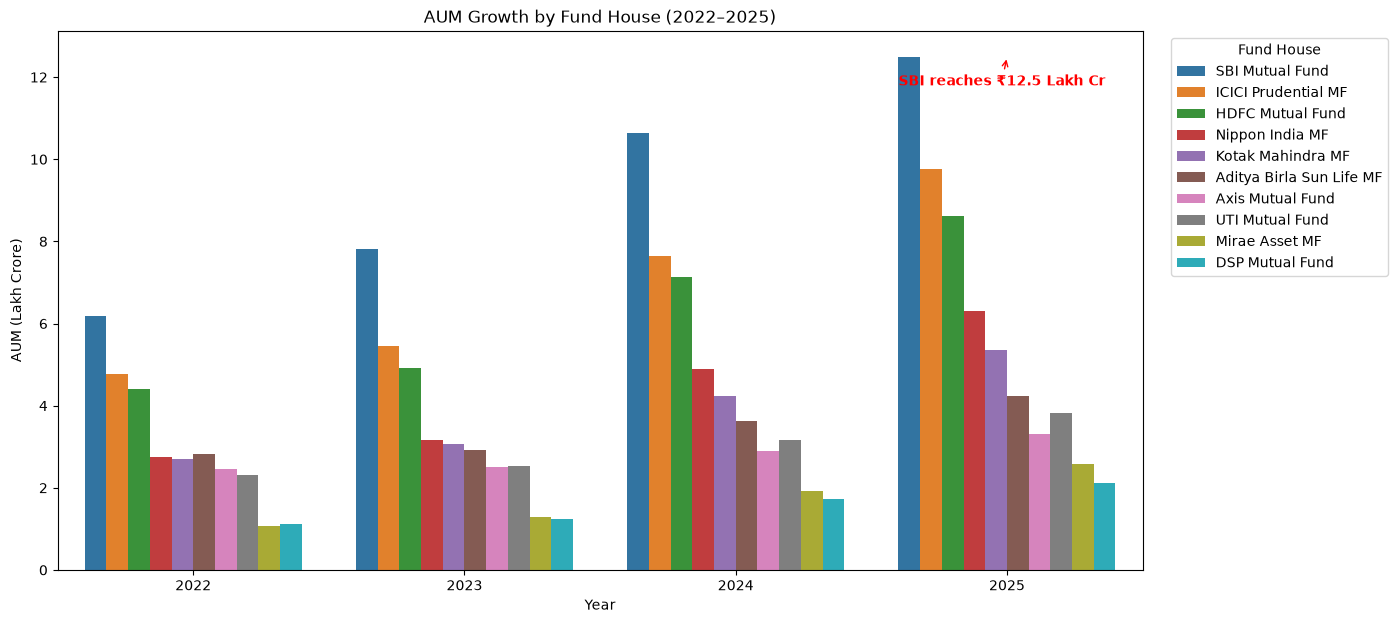

In [85]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum_df,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house",
    errorbar=None
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.legend(title="Fund House", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.annotate(
    "SBI reaches ₹12.5 Lakh Cr",
    xy=(3, 12.5),
    xytext=(2.6, 11.8),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=10,
    color="red",
    fontweight="bold"
)

plt.show()

## Business Insights

1. SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) from 2022–2025, reaching approximately ₹12.5 lakh crore in 2025.
2. ICICI Prudential MF and HDFC Mutual Fund also showed steady year-on-year AUM growth, reflecting strong investor confidence.
3. Almost all fund houses experienced continuous AUM growth during the four-year period, indicating expansion of the mutual fund industry.
4. SBI Mutual Fund's AUM grew at a faster pace than other fund houses, strengthening its market leadership.
5. The grouped bar chart clearly highlights the increasing gap between SBI Mutual Fund and other fund houses by 2025, demonstrating its dominant market position.

# Mission 3: SIP Inflow Time-Series

## Objective

Analyze the monthly Systematic Investment Plan (SIP) inflows from January 2022 to December 2025 using an interactive time-series line chart created with Plotly. Highlight the all-time highest SIP inflow of ₹31,002 Crore recorded in December 2025.

In [86]:

sip_df = pd.read_csv("../Data/Raw/04_monthly_sip_inflows.csv")

In [87]:
sip_df.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [88]:
sip_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.4 KB


In [89]:
sip_df.describe()

,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
count,48.000000,48.000000,48.000000,48.000000,36.000000
mean,19577.520833,7.189583,9.893750,8.632083,31.456944
std,6354.329621,1.271457,5.370745,3.613579,11.768190
min,11438.000000,4.910000,7.500000,4.800000,15.800000
25%,13658.500000,6.110000,8.775000,5.790000,20.245000
50%,18224.000000,7.150000,9.200000,7.265000,28.295000
75%,25944.250000,8.300000,9.562500,10.525000,40.807500
max,31002.000000,9.350000,46.000000,15.900000,53.050000


In [90]:
sip_df.isnull().sum()

month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

In [91]:
sip_df["month"] = pd.to_datetime(sip_df["month"])

In [92]:
sip_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      48 non-null     datetime64[us]
 1   sip_inflow_crore           48 non-null     int64         
 2   active_sip_accounts_crore  48 non-null     float64       
 3   new_sip_accounts_lakh      48 non-null     float64       
 4   sip_aum_lakh_crore         48 non-null     float64       
 5   yoy_growth_pct             36 non-null     float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 2.4 KB


In [93]:
import plotly.express as px

In [94]:
fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)",
    markers=True
)

In [95]:
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)

In [96]:
peak = sip_df[sip_df["sip_inflow_crore"] == sip_df["sip_inflow_crore"].max()]
peak

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
47,2025-12-01,31002,9.35,9.8,15.9,17.17


In [97]:
fig.add_annotation(
    x=peak["month"].iloc[0],
    y=peak["sip_inflow_crore"].iloc[0],
    text="All-Time High ₹31,002 Cr (Dec 2025)",
    showarrow=True,
    arrowhead=2,
    ax=-70,
    ay=-40,
    font=dict(color="red", size=12)
)

fig.show()

## Business Insights

1. Monthly SIP inflows showed a steady upward trend from January 2022 to December 2025, indicating consistent growth in systematic investments.
2. SIP inflows reached an all-time high of ₹31,002 Crore in December 2025, reflecting strong investor confidence in mutual funds.
3. A noticeable acceleration in SIP inflows was observed during 2024–2025, suggesting increased participation from retail investors.
4. Despite minor month-to-month fluctuations, the overall trend remained positive, demonstrating sustained long-term investment discipline.
5. The continuous rise in SIP inflows indicates a healthy expansion of the mutual fund industry and growing awareness of long-term wealth creation through SIPs.

# Mission 4: Category Inflow Heatmap

## Objective

Analyze monthly net inflows across different mutual fund categories using a Seaborn heatmap. Visualize months on the X-axis, fund categories on the Y-axis, and net inflow values through color intensity to identify investment trends and category-wise inflow patterns.

In [98]:
category_df = pd.read_csv("../Data/Raw/05_category_inflows.csv")

In [99]:
category_df.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [100]:
category_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    str    
 1   category          144 non-null    str    
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.5 KB


In [101]:
category_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    str    
 1   category          144 non-null    str    
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.5 KB


In [102]:
category_df.isnull().sum()

month               0
category            0
net_inflow_crore    0
dtype: int64

In [103]:
category_pivot = category_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

category_pivot.head()

month,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


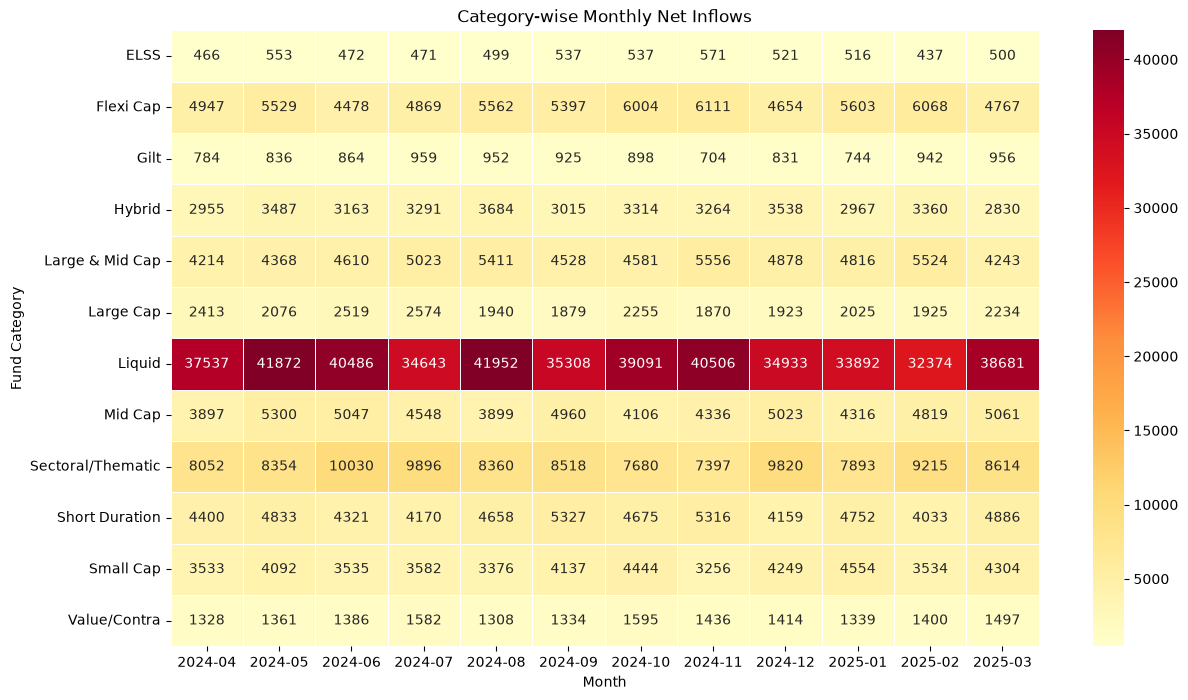

In [104]:
plt.figure(figsize=(14,8))

sns.heatmap(
    category_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Category-wise Monthly Net Inflows")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.show()

## Business Insights

1. Liquid Funds consistently recorded the highest monthly net inflows, significantly outperforming all other fund categories during the analysis period.
2. Flexi Cap, Large & Mid Cap, and Sectoral/Thematic funds attracted strong investor inflows, indicating sustained interest in equity-oriented investments.
3. ELSS and Gilt funds maintained comparatively lower net inflows throughout the period, reflecting relatively lower investor participation.
4. Monthly inflows varied across categories, highlighting changing investor preferences and market conditions over time.
5. The heatmap clearly shows that investor inflows were concentrated in a few major fund categories, with Liquid Funds dominating the overall inflow trend.

# Mission 5: Investor Demographics

## Objective

Analyze investor demographics using visualizations to understand the distribution of investors across different age groups and genders. Explore investment patterns through an age group distribution pie chart, SIP amount box plot by age group, and gender-wise investor split.

In [105]:
investor_df = pd.read_csv("../Data/Raw/08_investor_transactions.csv")

In [106]:
investor_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [107]:
investor_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 3.3 MB


In [108]:
investor_df.describe()

,amfi_code,amount_inr,annual_income_lakh
count,32778.000000,32778.000000,32778.000000
mean,120264.617518,107437.318628,26.181219
std,14370.205345,150415.905084,20.805425
min,100016.000000,400.000000,3.000000
25%,118632.000000,3153.000000,10.600000
50%,119551.000000,17782.500000,19.700000
75%,120843.000000,189324.250000,37.400000
max,149324.000000,597498.000000,99.700000


In [109]:
investor_df.isnull().sum()

investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group             0
gender                0
annual_income_lakh    0
payment_mode          0
kyc_status            0
dtype: int64

In [110]:
age_counts = investor_df["age_group"].value_counts()

age_counts

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

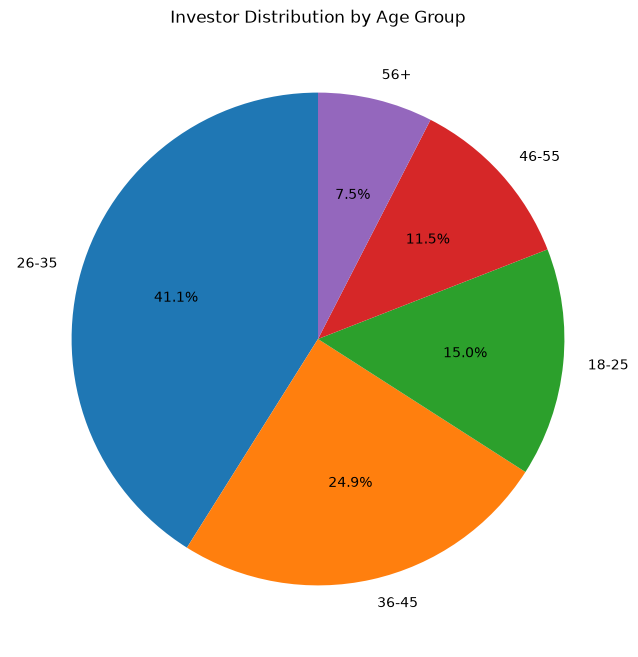

In [111]:
plt.figure(figsize=(8, 8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by Age Group")

plt.show()

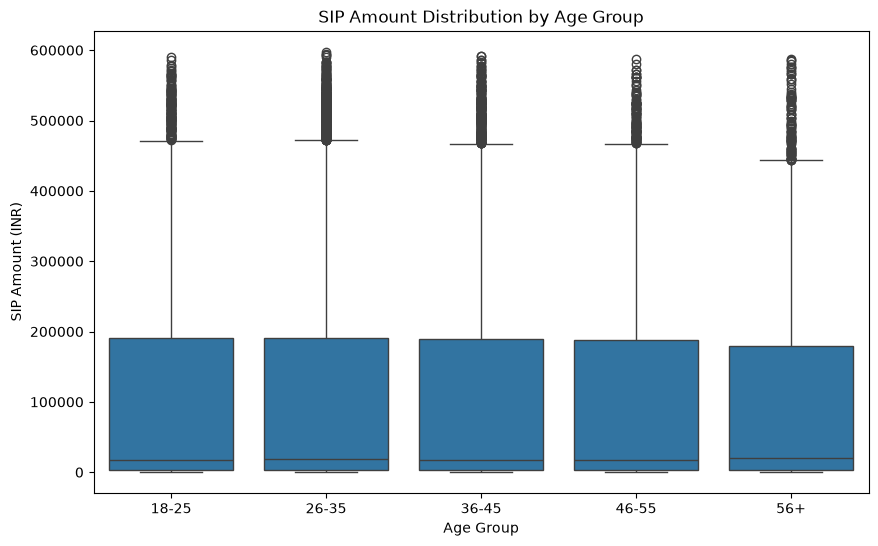

In [113]:
age_order = ["18-25", "26-35", "36-45", "46-55", "56+"]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor_df,
    x="age_group",
    y="amount_inr",
    order=age_order
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (INR)")

plt.show()

In [114]:
gender_counts = investor_df["gender"].value_counts()

gender_counts

gender
Male      21809
Female    10969
Name: count, dtype: int64

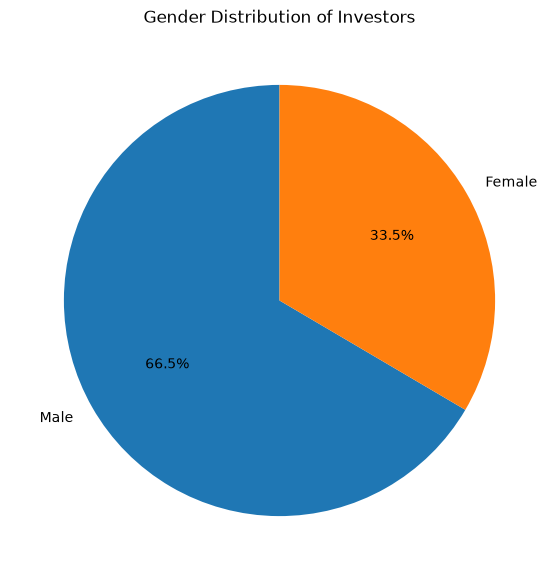

In [115]:
plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")

plt.show()

## Business Insights

1. The 26–35 age group accounted for the largest share of investors (41.1%), indicating that young working professionals are the most active participants in mutual fund investments.
2. Male investors represented 66.5% of the investor base, while female investors accounted for 33.5%, showing higher participation from male investors.
3. SIP amount distributions were broadly similar across all age groups, with comparable median investment levels.
4. Every age group contained several high-value investment outliers, indicating the presence of investors making significantly larger SIP contributions than the majority.
5. The combined demographic analysis suggests that mutual fund investments are primarily driven by working-age investors, with opportunities to increase participation among female and senior investors.

# Mission 6: Geographic Distribution

## Objective

Analyze the geographic distribution of SIP investments across different Indian states and city tiers. Visualize state-wise SIP amounts using a horizontal bar chart and compare investor distribution between Tier 30 (T30) and Beyond Top 30 (B30) cities using a pie chart.

In [116]:
state_sip = investor_df.groupby("state")["amount_inr"].sum().reset_index()

state_sip.head()

,state,amount_inr
0,Delhi,289633404
1,Gujarat,298358940
2,Haryana,279634354
3,Karnataka,273753570
4,Madhya Pradesh,308312493


In [118]:
state_sip = state_sip.sort_values(
    by="amount_inr",
    ascending=False
)

state_sip.head()

,state,amount_inr
6,Punjab,315780459
8,Tamil Nadu,315177237
4,Madhya Pradesh,308312493
7,Rajasthan,298645822
1,Gujarat,298358940


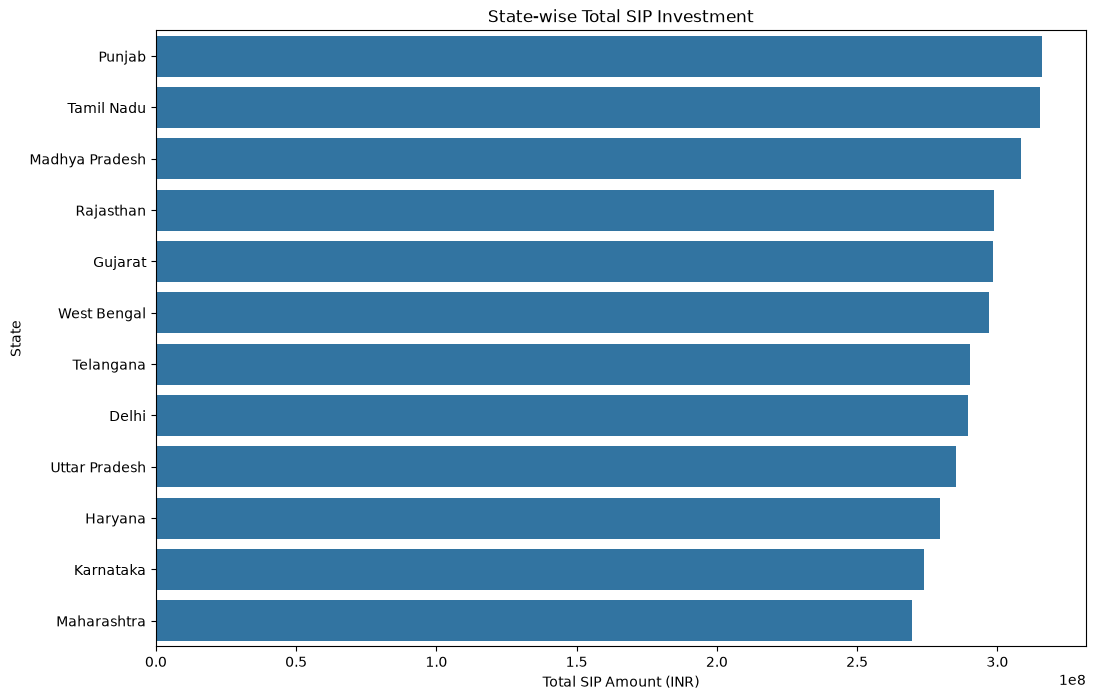

In [119]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=state_sip,
    x="amount_inr",
    y="state"
)

plt.title("State-wise Total SIP Investment")
plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.show()

In [120]:
city_tier_counts = investor_df["city_tier"].value_counts()

city_tier_counts

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

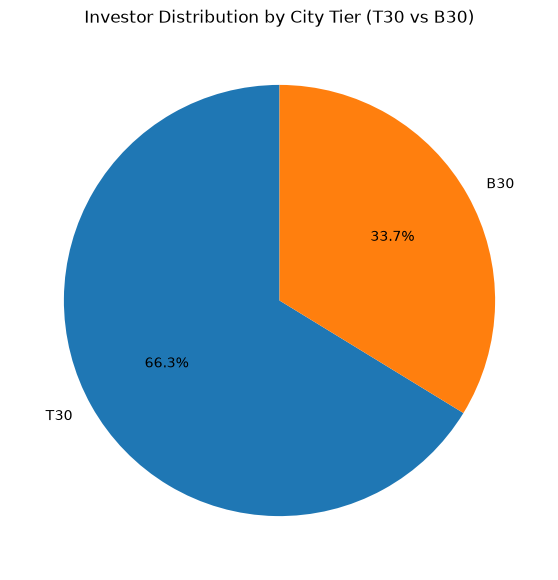

In [121]:
plt.figure(figsize=(7,7))

plt.pie(
    city_tier_counts,
    labels=city_tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by City Tier (T30 vs B30)")

plt.show()

## Business Insights

1. Punjab recorded the highest total SIP investment, followed closely by Tamil Nadu and Madhya Pradesh, indicating strong investor participation in these states.
2. Maharashtra and Karnataka showed comparatively lower total SIP investments among the selected states in the dataset.
3. The horizontal bar chart highlights noticeable differences in total SIP investments across states, reflecting regional variations in investor activity.
4. T30 cities accounted for 66.3% of all investor transactions, while B30 cities contributed 33.7%, indicating higher participation from investors in the top 30 cities.
5. The geographic analysis suggests that mutual fund adoption is stronger in major urban centers, while B30 cities present significant growth opportunities for expanding investor participation.

# Mission 7: Folio Count Growth

## Objective

Analyze the growth in mutual fund folio counts from January 2022 to December 2025 using a line chart. Visualize the overall growth trend and highlight important milestones during the analysis period.

In [123]:
folio_df = pd.read_csv("../Data/Raw/06_industry_folio_count.csv")

In [124]:
folio_df.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [125]:
folio_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     str    
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.1 KB


In [126]:
folio_df.describe()

,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
count,21.000000,21.000000,21.000000,21.000000,21.000000
mean,19.829524,13.880476,2.776190,1.190000,1.983333
std,4.583376,3.207799,0.640308,0.274864,0.459079
min,13.260000,9.280000,1.860000,0.800000,1.330000
25%,15.540000,10.880000,2.180000,0.930000,1.550000
50%,19.980000,13.990000,2.800000,1.200000,2.000000
75%,23.890000,16.720000,3.340000,1.430000,2.390000
max,26.120000,18.280000,3.660000,1.570000,2.610000


In [127]:
folio_df.isnull().sum()

month                  0
total_folios_crore     0
equity_folios_crore    0
debt_folios_crore      0
hybrid_folios_crore    0
others_folios_crore    0
dtype: int64

In [128]:
folio_df["month"] = pd.to_datetime(folio_df["month"])

In [131]:
start = folio_df.iloc[0]
end = folio_df.iloc[-1]

start
end

month                  2025-12-01 00:00:00
total_folios_crore                   26.12
equity_folios_crore                  18.28
debt_folios_crore                     3.66
hybrid_folios_crore                   1.57
others_folios_crore                   2.61
Name: 20, dtype: object

In [132]:
import plotly.express as px

fig = px.line(
    folio_df,
    x="month",
    y="total_folios_crore",
    title="Mutual Fund Folio Growth (Jan 2022 - Dec 2025)",
    markers=True
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)"
)

fig.add_annotation(
    x=start["month"],
    y=start["total_folios_crore"],
    text="Start: 13.26 Cr (Jan 2022)",
    showarrow=True,
    arrowhead=2,
    ax=40,
    ay=40,
    font=dict(color="green", size=12)
)

fig.add_annotation(
    x=end["month"],
    y=end["total_folios_crore"],
    text="26.12 Cr (Dec 2025)",
    showarrow=True,
    arrowhead=2,
    ax=-80,
    ay=-40,
    font=dict(color="red", size=12)
)


fig.show()

## Business Insights

1. The total mutual fund folio count increased steadily from **13.26 crore in January 2022** to **26.12 crore in December 2025**, indicating strong long-term industry growth.
2. Folio growth accelerated significantly during 2024, reflecting increased investor participation in mutual funds.
3. The consistent upward trend throughout the analysis period suggests growing investor confidence in mutual fund investments.
4. No major decline in folio counts was observed, indicating sustained expansion of the mutual fund industry.
5. The doubling of folio counts over four years highlights the increasing adoption of mutual funds across retail investors.

In [133]:
nav_df = pd.read_csv("../Data/Raw/02_nav_history.csv")

In [134]:
nav_df.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [135]:
nav_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [136]:
nav_df.describe()

,amfi_code,nav
count,46000.000000,46000.000000
mean,120247.000000,269.570265
std,14352.317221,577.187060
min,100016.000000,26.136600
25%,118632.750000,69.170425
50%,119551.500000,122.732150
75%,120842.250000,260.338675
max,149324.000000,4268.549700


In [137]:
nav_df.isnull().sum()

amfi_code    0
date         0
nav          0
dtype: int64

In [138]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

In [139]:
nav_pivot = nav_df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

nav_pivot.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339,...,49.9131,3180.6318,560.1443,117.5969,70.2514,84.0757,28.8620,348.7159,78.4622,81.6814
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033,...,50.8195,3181.4042,560.7052,117.0077,71.6085,85.4096,29.1038,345.7198,78.5000,80.8239
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564,...,50.1942,3182.8754,563.0884,116.4011,71.3264,84.7554,29.5489,343.4795,79.1806,80.6143
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088,...,50.6213,3184.9450,561.0675,116.0861,72.1746,84.3563,29.5744,342.1680,78.0831,79.9386
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585,...,49.9391,3185.5042,559.5420,114.6164,72.2118,84.9469,29.6091,340.7757,78.4202,80.8723


In [140]:
correlation_matrix = nav_pivot.corr()

correlation_matrix.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
amfi_code,,,,,,,,,,,,,,,,,,,,,
100016,1.000000,0.585294,0.653467,0.566001,0.635922,0.722105,0.685988,0.552257,0.600189,0.693614,...,0.675490,0.723295,0.609280,0.683347,0.536224,0.783236,0.686310,0.621316,0.661151,0.636282
100025,0.585294,1.000000,0.912157,0.913252,0.574509,0.950664,0.954599,0.446243,0.955019,0.925264,...,0.945746,0.951927,0.901961,0.855493,0.962850,0.882981,0.941095,0.954733,0.944475,0.884016
100033,0.653467,0.912157,1.000000,0.952862,0.594425,0.968806,0.942302,0.535159,0.903926,0.918321,...,0.970335,0.965703,0.914544,0.903086,0.920934,0.913519,0.950956,0.953623,0.948999,0.897644
101206,0.566001,0.913252,0.952862,1.000000,0.435032,0.930026,0.944701,0.368374,0.910639,0.921962,...,0.932191,0.929256,0.955023,0.861620,0.941661,0.834258,0.936343,0.933261,0.902085,0.939610
101207,0.635922,0.574509,0.594425,0.435032,1.000000,0.691878,0.597639,0.708352,0.538029,0.566107,...,0.658125,0.690448,0.455587,0.696565,0.515995,0.782388,0.644144,0.563943,0.667936,0.404334


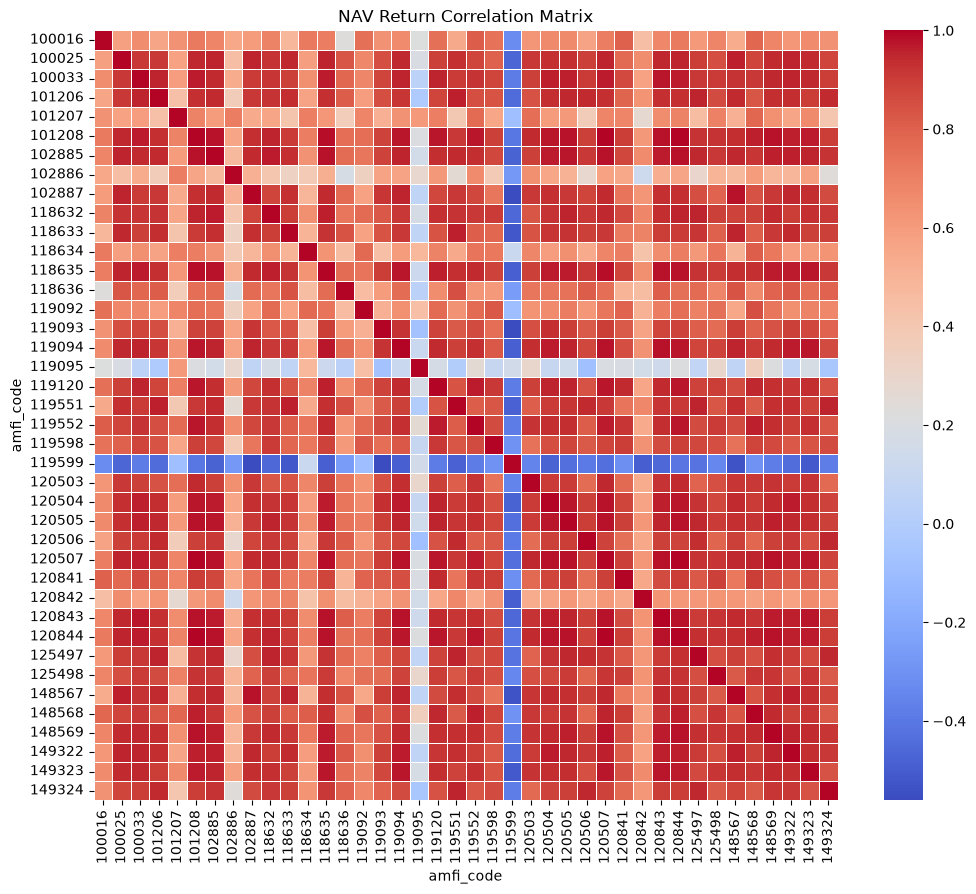

In [141]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("NAV Return Correlation Matrix")
plt.show()

## Business Insights

1. Most mutual fund schemes show strong positive correlation, indicating that they generally move in the same market direction.
2. Several fund pairs have very high correlation, suggesting similar investment strategies or exposure to common market sectors.
3. A few schemes exhibit weaker or negative correlations, which may provide diversification benefits in a portfolio.
4. The correlation matrix helps investors identify highly related funds and avoid unnecessary portfolio overlap.
5. Heatmap visualization provides a quick overview of relationships between multiple mutual fund schemes, making portfolio analysis easier.

# Mission 9: Sector Allocation Donut Chart

## Objective

Analyze the sector-wise allocation of mutual fund portfolio holdings by aggregating sector weights across all equity funds. Visualize the sector distribution using a donut chart to understand which sectors receive the highest portfolio allocation.

In [142]:
holding_df = pd.read_csv("../Data/Raw/09_portfolio_holdings.csv")

In [143]:
holding_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [144]:
holding_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [145]:
holding_df.describe()

,amfi_code,weight_pct,market_value_cr,current_price_inr
count,322.000000,322.000000,322.000000,322.000000
mean,121210.434783,10.558975,1008.846646,4080.870528
std,14669.377920,6.060137,543.827535,2265.186353
min,100016.000000,0.990000,55.740000,246.780000
25%,118633.000000,6.015000,513.702500,2081.985000
50%,119552.000000,9.395000,1045.670000,4138.995000
75%,120842.750000,13.917500,1477.502500,5914.307500
max,149324.000000,38.180000,1999.500000,7942.960000


In [146]:
holding_df.isnull().sum()

amfi_code            0
stock_symbol         0
stock_name           0
sector               0
weight_pct           0
market_value_cr      0
current_price_inr    0
portfolio_date       0
dtype: int64

In [147]:
sector_allocation = holding_df.groupby("sector")["weight_pct"].sum().reset_index()

sector_allocation

,sector,weight_pct
0,Automobile,323.65
1,Banking,652.26
2,Cement,105.03
3,Consumer Goods,127.61
4,Diversified,169.23
5,Energy,117.91
6,FMCG,229.11
7,IT,455.47
8,Infrastructure,192.16
9,NBFC,119.09


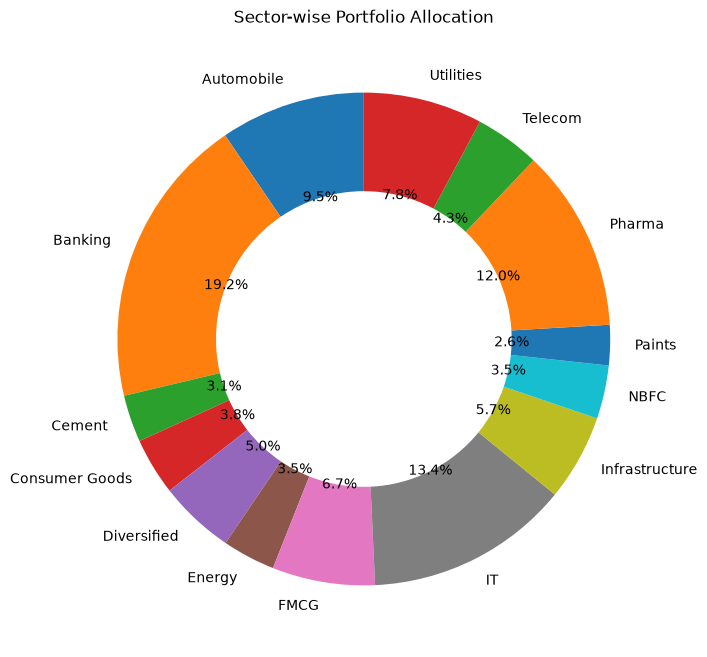

In [148]:
plt.figure(figsize=(8, 8))

plt.pie(
    sector_allocation["weight_pct"],
    labels=sector_allocation["sector"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)

plt.title("Sector-wise Portfolio Allocation")

plt.show()

## Business Insights

1. Banking has the highest portfolio allocation (19.2%), indicating that mutual funds have significant exposure to the banking sector.
2. IT and Pharma are among the major sectors with high portfolio weights, reflecting their importance in equity portfolios.
3. Sectors such as Paints, Cement, and Consumer Goods have relatively lower allocations compared to Banking and IT.
4. The portfolio is diversified across multiple sectors, reducing dependence on a single industry.
5. The donut chart provides a clear visualization of sector-wise portfolio allocation, helping investors understand sector concentration and diversification.

# Mission 10: Key EDA Findings

## Objective

Summarize the most important insights discovered during the Exploratory Data Analysis (EDA). Document key observations from each analysis with supporting chart references to provide a concise business summary of the mutual fund dataset.

# Mission 10: Key EDA Findings

## Key EDA Findings

1. Most mutual fund schemes showed a consistent long-term increase in NAV, indicating positive growth over the analysis period.
   - **Reference:** Mission 1 – NAV Trend Analysis

2. Assets Under Management (AUM) increased steadily across major fund houses, reflecting growing investor participation.
   - **Reference:** Mission 2 – AUM Growth Bar Chart

3. Monthly SIP inflows showed a strong upward trend and reached an all-time high by the end of 2025.
   - **Reference:** Mission 3 – SIP Inflow Time Series

4. Liquid funds attracted the highest monthly net inflows compared to other fund categories.
   - **Reference:** Mission 4 – Category Inflow Heatmap

5. Investors aged 26–35 formed the largest investor group, indicating strong participation from young professionals.
   - **Reference:** Mission 5 – Investor Demographics

6. T30 cities contributed significantly more investors than B30 cities, highlighting higher mutual fund adoption in metro and large urban regions.
   - **Reference:** Mission 6 – Geographic Distribution

7. Total mutual fund folios increased consistently from 2022 to 2025, reflecting continuous growth in the investor base.
   - **Reference:** Mission 7 – Folio Count Growth

8. Most mutual fund schemes exhibited strong positive NAV correlations, suggesting that many funds moved in similar market directions.
   - **Reference:** Mission 8 – NAV Return Correlation Matrix

9. Banking, IT, and Pharma sectors accounted for the largest share of portfolio allocation, indicating these sectors dominate equity mutual fund investments.
   - **Reference:** Mission 9 – Sector Allocation Donut Chart

10. Overall, the EDA reveals healthy growth in investor participation, rising SIP inflows, increasing folios, and diversified sector allocations, indicating a strong and expanding mutual fund industry.
    - **Reference:** Overall EDA Summary